<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/R_codes/Data_analysis_using_R_HW3_BOIS511_Rmd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
library(tidyr)
library(dplyr) # dplyr is needed for grouping and summarizing

# Load the sample data
tidyr::who

# The who_tb data is in a wide format and needs to be tidied first
# We can use pivot_longer to gather the diagnosis columns
who_tidy <- who %>%
  pivot_longer(
    cols = new_sp_m014:newrel_f65,
    names_to = "key",
    values_to = "cases"
  ) %>%
  # Remove missing values
  filter(!is.na(cases))

# Now we can group and summarize the data
# For example, group by country and year to get total cases per country per year
cases_by_country_year <- who_tidy %>%
  group_by(country, year) %>%
  summarise(total_cases = sum(cases))

# Display the result
print(cases_by_country_year)

# You can also group by other columns, for example, by country and sex
# To do this, we need to extract sex and age group from the 'key' column
cases_by_country_sex <- who_tidy %>%
  mutate(
    sex = substr(key, 7, 7), # Extract sex (m or f)
    age_group = substr(key, 8, nchar(key)) # Extract age group
  ) %>%
  group_by(country, sex) %>%
  summarise(total_cases = sum(cases))

# Display the result
print(cases_by_country_sex)

# To demonstrate combining data, let's create a dummy data frame
dummy_data <- data.frame(
  country = unique(who_tidy$country),
  population = sample(1000000:10000000, size = length(unique(who_tidy$country)), replace = TRUE)
)

# Now we can combine the summarized data with the dummy data using left_join
cases_with_population <- left_join(cases_by_country_year, dummy_data, by = "country")

# Display the combined data
print(cases_with_population)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,⋯,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Afghanistan,AF,AFG,1980,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1981,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1982,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1983,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1984,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1985,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1986,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1987,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
Afghanistan,AF,AFG,1988,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


`summarise()` has grouped output by 'country'. You can override using the
`.groups` argument.


# A tibble: 3,484 × 3
# Groups:   country [219]
   country      year total_cases
   <chr>       <dbl>       <dbl>
 1 Afghanistan  1997         128
 2 Afghanistan  1998        1778
 3 Afghanistan  1999         745
 4 Afghanistan  2000        2666
 5 Afghanistan  2001        4639
 6 Afghanistan  2002        6509
 7 Afghanistan  2003        6528
 8 Afghanistan  2004        8245
 9 Afghanistan  2005        9949
10 Afghanistan  2006       12469
# ℹ 3,474 more rows


`summarise()` has grouped output by 'country'. You can override using the
`.groups` argument.


# A tibble: 219 × 3
# Groups:   country [219]
   country             sex   total_cases
   <chr>               <chr>       <dbl>
 1 Afghanistan         _          140225
 2 Albania             _            5335
 3 Algeria             _          128119
 4 American Samoa      _              41
 5 Andorra             _             103
 6 Angola              _          308365
 7 Anguilla            _               2
 8 Antigua and Barbuda _              55
 9 Argentina           _          117156
10 Armenia             _           15991
# ℹ 209 more rows
# A tibble: 3,484 × 4
# Groups:   country [219]
   country      year total_cases population
   <chr>       <dbl>       <dbl>      <int>
 1 Afghanistan  1997         128    8979933
 2 Afghanistan  1998        1778    8979933
 3 Afghanistan  1999         745    8979933
 4 Afghanistan  2000        2666    8979933
 5 Afghanistan  2001        4639    8979933
 6 Afghanistan  2002        6509    8979933
 7 Afghanistan  2003        6528    8979933


In [ ]:
who_tidy

country,iso2,iso3,year,key,cases
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
Afghanistan,AF,AFG,1997,new_sp_m014,0
Afghanistan,AF,AFG,1997,new_sp_m1524,10
Afghanistan,AF,AFG,1997,new_sp_m2534,6
Afghanistan,AF,AFG,1997,new_sp_m3544,3
Afghanistan,AF,AFG,1997,new_sp_m4554,5
Afghanistan,AF,AFG,1997,new_sp_m5564,2
Afghanistan,AF,AFG,1997,new_sp_m65,0
Afghanistan,AF,AFG,1997,new_sp_f014,5
Afghanistan,AF,AFG,1997,new_sp_f1524,38


In [ ]:
# group by country, ses and year by mu tating the data
cases_by_country_sex_year <- who_tidy %>%
  mutate(
  sex = substr(key, 8, 8),
  age_group = substr(key, 9,nchar(key))
  ) %>%
  group_by(country,year,sex) %>%
  summarise(total_cases = sum(cases))

`summarise()` has grouped output by 'country', 'year'. You can override using
the `.groups` argument.


In [ ]:
print(cases_by_country_sex_year)

# A tibble: 6,921 × 4
# Groups:   country, year [3,484]
   country      year sex   total_cases
   <chr>       <dbl> <chr>       <dbl>
 1 Afghanistan  1997 f             102
 2 Afghanistan  1997 m              26
 3 Afghanistan  1998 f            1207
 4 Afghanistan  1998 m             571
 5 Afghanistan  1999 f             517
 6 Afghanistan  1999 m             228
 7 Afghanistan  2000 f            1751
 8 Afghanistan  2000 m             915
 9 Afghanistan  2001 f            3062
10 Afghanistan  2001 m            1577
# ℹ 6,911 more rows


In [ ]:
# cases by country
cases_country <- who_tidy %>%
  group_by(country) %>%
  summarise(total_cases = sum(cases))

print(cases_country)

# A tibble: 219 × 2
   country             total_cases
   <chr>                     <dbl>
 1 Afghanistan              140225
 2 Albania                    5335
 3 Algeria                  128119
 4 American Samoa               41
 5 Andorra                     103
 6 Angola                   308365
 7 Anguilla                      2
 8 Antigua and Barbuda          55
 9 Argentina                117156
10 Armenia                   15991
# ℹ 209 more rows


In [ ]:
# cases by the sex
cases_sex <- who_tidy %>%
  mutate(
  sex = substr(key, 8, 8),
  age_group = substr(key, 9,nchar(key))
  ) %>%
  group_by(sex) %>%
  summarise(total_cases = sum(cases))

print(cases_sex)

# A tibble: 2 × 2
  sex   total_cases
  <chr>       <dbl>
1 f        15907024
2 m        27490494


In [ ]:
# cases by year
cases_year <- who_tidy %>%
  mutate(
  sex = substr(key, 8, 8),
  age_group = substr(key, 9,nchar(key))
  ) %>%
  group_by(year) %>%
  summarise(total_cases = sum(cases))

print(cases_year)

# A tibble: 34 × 2
    year total_cases
   <dbl>       <dbl>
 1  1980         959
 2  1981         805
 3  1982         824
 4  1983         786
 5  1984         814
 6  1985         799
 7  1986         754
 8  1987         670
 9  1988         682
10  1989         654
# ℹ 24 more rows


In [ ]:
# country with highest cases reported in the year 2010
high_case <- filter(who_tidy, year==2010)
high_case_country <- high_case %>%
  group_by(country) %>%
  summarise(ttl_cases = sum(cases))
print(high_case_country)

arrange(high_case_country, desc(ttl_cases))


# A tibble: 204 × 2
   country             ttl_cases
   <chr>                   <dbl>
 1 Afghanistan             12947
 2 Albania                   415
 3 Algeria                  8299
 4 American Samoa              4
 5 Andorra                     7
 6 Angola                  21146
 7 Anguilla                    1
 8 Antigua and Barbuda         6
 9 Argentina                6827
10 Armenia                  1329
# ℹ 194 more rows


country,ttl_cases
<chr>,<dbl>
China,869092
India,630164
South Africa,364992
Indonesia,296272
Bangladesh,150856
Pakistan,124455
Russian Federation,102823
Philippines,89198
Kenya,85484


In [ ]:
# The total number of TB cases reported for males versus females across all countries in each year.
total_cases_by_year_sex <- who_tidy %>%
  mutate(
  sex = substr(key, 8, 8),
  age_group = substr(key, 9,nchar(key))
  ) %>%
  group_by(year,sex) %>%
  summarise(total_cases = sum(cases))

print(total_cases_by_year_sex)

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


# A tibble: 68 × 3
# Groups:   year [34]
    year sex   total_cases
   <dbl> <chr>       <dbl>
 1  1980 f             337
 2  1980 m             622
 3  1981 f             291
 4  1981 m             514
 5  1982 f             293
 6  1982 m             531
 7  1983 f             295
 8  1983 m             491
 9  1984 f             311
10  1984 m             503
# ℹ 58 more rows


In [ ]:
# Create a new column that calculates the proportion of total TB cases in males versus females for each country in 2013.
total_cases_by_year_2013 <- who_tidy %>%
  mutate(
  sex = substr(key, 8, 8),
  age_group = substr(key, 9,nchar(key))
  ) %>%
  filter(year==2013)  %>%
  group_by(country,sex) %>%
  summarise(t_cases = sum(cases))

print(total_cases_by_year_2013)

`summarise()` has grouped output by 'country'. You can override using the
`.groups` argument.


# A tibble: 388 × 3
# Groups:   country [196]
   country     sex   t_cases
   <chr>       <chr>   <dbl>
 1 Afghanistan f        1749
 2 Afghanistan m        1705
 3 Albania     f         146
 4 Albania     m         328
 5 Algeria     f        2819
 6 Algeria     m        4305
 7 Andorra     f           1
 8 Andorra     m           4
 9 Angola      f        9207
10 Angola      m       12454
# ℹ 378 more rows


In [ ]:
cases_by_2013_mf <- total_cases_by_year_2013 %>%
  pivot_wider(
     names_from = sex,        # take unique values from "sex"
     values_from = t_cases,   # fill with values from "t_cases"
     names_prefix = "cases_"
  ) %>%
  mutate(
  ratio = cases_m / cases_f
  )
print(cases_by_2013_mf)

# A tibble: 196 × 4
# Groups:   country [196]
   country             cases_f cases_m   ratio
   <chr>                 <dbl>   <dbl>   <dbl>
 1 Afghanistan            1749    1705   0.975
 2 Albania                 146     328   2.25 
 3 Algeria                2819    4305   1.53 
 4 Andorra                   1       4   4    
 5 Angola                 9207   12454   1.35 
 6 Anguilla                  0       0 NaN    
 7 Antigua and Barbuda       1       9   9    
 8 Argentina              3779    5113   1.35 
 9 Armenia                 329    1068   3.25 
10 Aruba                     6       5   0.833
# ℹ 186 more rows


In [ ]:
# visualise the trend in total TB cases over time for China, using different colors to differentiate between male and female cases.


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


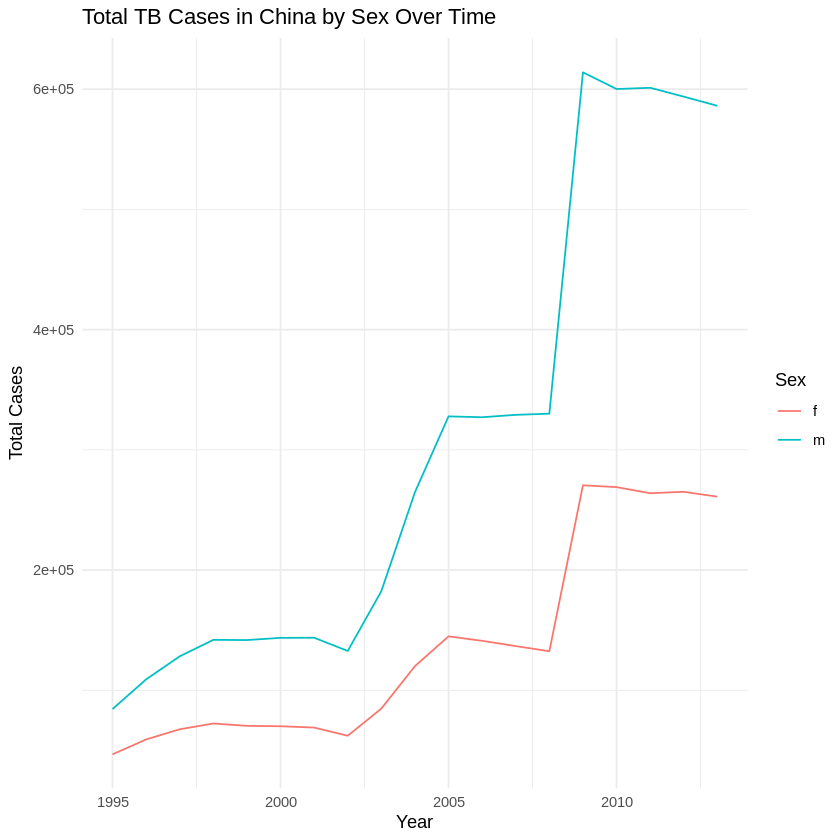

In [ ]:
library(ggplot2)

# Filter data for China and group by year and sex
china_cases_by_year_sex <- who_tidy %>%
  filter(country == "China") %>%
  mutate(
    sex = substr(key, 8, 8),
    age_group = substr(key, 9,nchar(key))
  ) %>%
  group_by(year, sex) %>%
  summarise(total_cases = sum(cases))

# Create a line plot
ggplot(china_cases_by_year_sex, aes(x = year, y = total_cases, color = sex)) +
  geom_line() +
  labs(title = "Total TB Cases in China by Sex Over Time",
       x = "Year",
       y = "Total Cases",
       color = "Sex") +
  theme_minimal()

`summarise()` has grouped output by 'age_group'. You can override using the
`.groups` argument.


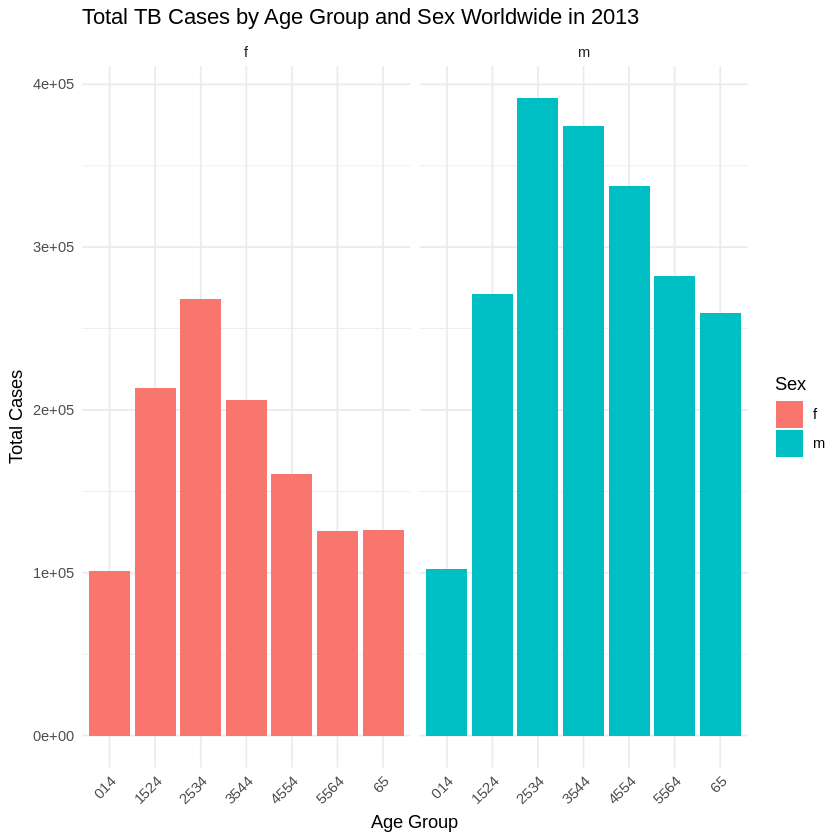

In [46]:
# Compare the distribution of total TB cases for different age groups worldwide in 2013, using `facet_wrap()` to create separate plots for males and females.
library(ggplot2)

# Filter data for 2013, extract sex and age group, and summarize total cases by age group and sex
cases_2013_age_sex <- who_tidy %>%
  filter(year == 2013) %>%
  mutate(
    sex = substr(key, 8, 8),
    age_group = substr(key, 9, nchar(key))
  ) %>%
  group_by(age_group, sex) %>%
  summarise(total_cases = sum(cases)) %>%
  filter(age_group != "") # Remove cases where age group is not defined

# Create a bar plot faceted by sex
ggplot(cases_2013_age_sex, aes(x = age_group, y = total_cases, fill = sex)) +
  geom_bar(stat = "identity", position = "dodge") +
  facet_wrap(~ sex) +
  labs(title = "Total TB Cases by Age Group and Sex Worldwide in 2013",
       x = "Age Group",
       y = "Total Cases",
       fill = "Sex") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) # Rotate x-axis labels for readability

In [ ]:
# Create a map to visualize the proportion of total TB cases in males for each country in 2013. You can use the packages `rnaturalearth` and `rnaturalearthdata`.

## nycfilghts dataset analysis

In [ ]:
install.packages("nycflights13")
library("nycflights13")
flights

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00
2013,1,1,555,600,-5,913,854,19,B6,507,N516JB,EWR,FLL,158,1065,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,709,723,-14,EV,5708,N829AS,LGA,IAD,53,229,6,0,2013-01-01 06:00:00
2013,1,1,557,600,-3,838,846,-8,B6,79,N593JB,JFK,MCO,140,944,6,0,2013-01-01 06:00:00


In [ ]:
airlines

carrier,name
<chr>,<chr>
9E,Endeavor Air Inc.
AA,American Airlines Inc.
AS,Alaska Airlines Inc.
B6,JetBlue Airways
DL,Delta Air Lines Inc.
EV,ExpressJet Airlines Inc.
F9,Frontier Airlines Inc.
FL,AirTran Airways Corporation
HA,Hawaiian Airlines Inc.


In [ ]:
airports

faa,name,lat,lon,alt,tz,dst,tzone
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
04G,Lansdowne Airport,41.13047,-80.61958,1044,-5,A,America/New_York
06A,Moton Field Municipal Airport,32.46057,-85.68003,264,-6,A,America/Chicago
06C,Schaumburg Regional,41.98934,-88.10124,801,-6,A,America/Chicago
06N,Randall Airport,41.43191,-74.39156,523,-5,A,America/New_York
09J,Jekyll Island Airport,31.07447,-81.42778,11,-5,A,America/New_York
0A9,Elizabethton Municipal Airport,36.37122,-82.17342,1593,-5,A,America/New_York
0G6,Williams County Airport,41.46731,-84.50678,730,-5,A,America/New_York
0G7,Finger Lakes Regional Airport,42.88356,-76.78123,492,-5,A,America/New_York
0P2,Shoestring Aviation Airfield,39.79482,-76.64719,1000,-5,U,America/New_York


In [ ]:
planes

tailnum,year,type,manufacturer,model,engines,seats,speed,engine
<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>
N10156,2004,Fixed wing multi engine,EMBRAER,EMB-145XR,2,55,NA,Turbo-fan
N102UW,1998,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan
N103US,1999,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan
N104UW,1999,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan
N10575,2002,Fixed wing multi engine,EMBRAER,EMB-145LR,2,55,NA,Turbo-fan
N105UW,1999,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan
N107US,1999,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan
N108UW,1999,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan
N109UW,1999,Fixed wing multi engine,AIRBUS INDUSTRIE,A320-214,2,182,NA,Turbo-fan


In [ ]:
(delays <- flights %>%
  group_by(dest) %>%
  summarise(
    count = n(),
    dist = mean(distance, na.rm = TRUE),
    delay = mean(arr_delay, na.rm = TRUE)
  ) %>%
  filter(count > 20, dest != "HNL"))

dest,count,dist,delay
<chr>,<int>,<dbl>,<dbl>
ABQ,254,1826.0000,4.3818898
ACK,265,199.0000,4.8522727
ALB,439,143.0000,14.3971292
ATL,17215,757.1082,11.3001128
AUS,2439,1514.2530,6.0199088
AVL,275,583.5818,8.0038314
BDL,443,116.0000,7.0485437
BGR,375,378.0000,8.0279330
BHM,297,865.9966,16.8773234


# Task
Create a map to visualize the proportion of total TB cases in males for each country in 2013. You can use the packages `rnaturalearth` and `rnaturalearthdata`.

## Calculate male proportion

### Subtask:
Calculate the proportion of total TB cases that are male for each country in 2013.


**Reasoning**:
Calculate the proportion of male cases for each country in 2013 and handle potential division by zero.



In [58]:
cases_by_2013_mf <- cases_by_2013_mf %>%
  mutate(
    male_proportion = if_else(cases_m + cases_f == 0, NA_real_, cases_m / (cases_m + cases_f))
  )

print(cases_by_2013_mf)

# A tibble: 196 × 5
# Groups:   sovereignt [196]
   sovereignt          cases_f cases_m   ratio male_proportion
   <chr>                 <dbl>   <dbl>   <dbl>           <dbl>
 1 Afghanistan            1749    1705   0.975           0.494
 2 Albania                 146     328   2.25            0.692
 3 Algeria                2819    4305   1.53            0.604
 4 Andorra                   1       4   4               0.8  
 5 Angola                 9207   12454   1.35            0.575
 6 Anguilla                  0       0 NaN              NA    
 7 Antigua and Barbuda       1       9   9               0.9  
 8 Argentina              3779    5113   1.35            0.575
 9 Armenia                 329    1068   3.25            0.764
10 Aruba                     6       5   0.833           0.455
# ℹ 186 more rows


In [57]:
# rename the country to sovereignt column name
cases_by_2013_mf <- cases_by_2013_mf %>%
  rename(
  sovereignt = country
  )

ERROR: [1m[33mError[39m in `rename()`:[22m
[33m![39m Can't rename columns that don't exist.
[31m✖[39m Column `country` doesn't exist.


## Get world map data

### Subtask:
Load spatial data for the world map using `rnaturalearth` and `rnaturalearthdata`.


**Reasoning**:
Load the necessary libraries for spatial data and retrieve world map data.



**Reasoning**:
The required package `rnaturalearth` is not installed. Install the package and try again.



In [ ]:
install.packages("rnaturalearthdata")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



# Task
Explain the error in the selected code, fix it if possible, and incorporate the changes into the existing code. Otherwise, diagnose the error.

## Analyze the map

### Subtask:
Interpret the choropleth map to identify any patterns or trends in the proportion of male TB cases across different countries.


**Reasoning**:
The previous cell failed because the `rnaturalearthdata` package was not installed. I need to install this package before I can generate the map. I will then proceed to generate and interpret the map to identify patterns.



In [47]:
if (!requireNamespace("pacman", quietly = TRUE)) install.packages("pacman")
# Load all required libraries
pacman::p_load(tidyverse, rnaturalearth, rnaturalearthdata, sf, ggplot2, scales)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘s2’, ‘sf’, ‘terra’


Warning message in utils::install.packages(package, ...):
“installation of package ‘terra’ had non-zero exit status”
Warning message in utils::install.packages(package, ...):
“installation of package ‘rnaturalearth’ had non-zero exit status”
Warning message in p_install(package, character.only = TRUE, ...):
“”
Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘rnaturalearth’”
Warning message in pacman::p_load(tidyverse, rnaturalearth, rnaturalearthdata, sf, :
“Failed to install/load:
rnaturalearth”


In [ ]:
install.packages("rnaturalearthdata")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [50]:
install.packages("rnaturalearth")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘terra’




**Reasoning**:
Now that `rnaturalearthdata` is installed, I can load the necessary libraries and create the choropleth map to visualize the proportion of male TB cases and interpret the patterns and trends.



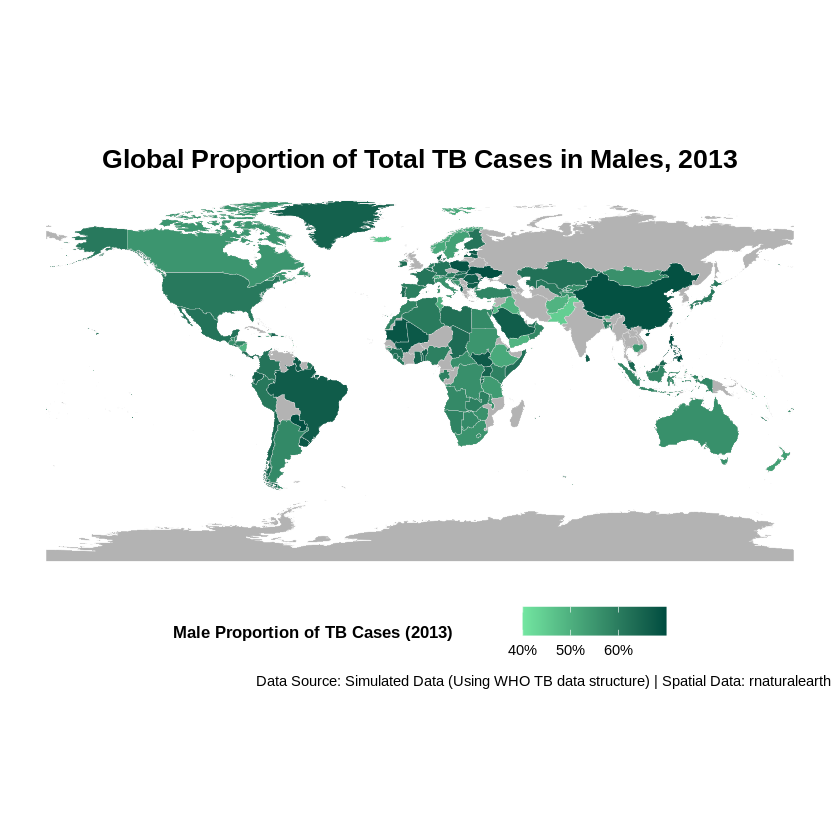

In [63]:
library(ggplot2)
library(rnaturalearth)
library(rnaturalearthdata)
library(dplyr)
library(sf)

world_map <- ne_countries(scale = "medium", returnclass = "sf") %>%
  # Select only the columns needed to simplify the dataset
  select(sovereignt, iso_a3, geometry)


# 4. Merge TB Data with Map Data
# Join the TB data onto the world map data using the ISO A3 code.
map_data_merged <- left_join(
  world_map,
  cases_by_2013_mf,
  by = "sovereignt"
)


# 5. Create the Choropleth Map Visualization
tb_map <- ggplot(data = map_data_merged) +
  # Use geom_sf to draw the map based on the 'male_proportion' variable
  geom_sf(aes(fill = male_proportion), color = "gray90", size = 0.1) +
  # Define the color scale (a continuous scale from low to high proportion)
  scale_fill_gradient(
    name = "Male Proportion of TB Cases (2013)",
    low = "#73E6A1",  # Lighter Green (Lower Proportion)
    high = "#004D40", # Darker Green (Higher Proportion)
    na.value = "gray70", # Color for countries with no data (NA)
    limits = c(0.4, 0.7), # Set a fixed range for better comparison
    labels = scales::percent
  ) +
  # Customize the map theme for clarity and aesthetics
  labs(
    title = "Global Proportion of Total TB Cases in Males, 2013",
    caption = "Data Source: Simulated Data (Using WHO TB data structure) | Spatial Data: rnaturalearth"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.position = "bottom",
    legend.title = element_text(size = 10, face = "bold"),
    axis.title = element_blank(),
    axis.text = element_blank(),
    panel.grid.major = element_line(color = "transparent"), # Remove major grid lines
    panel.border = element_blank(), # Remove map border
    plot.background = element_rect(fill = "white", color = NA)
  )

# Display the map
print(tb_map)